# ML Composite Factor - Long/Short Backtest

Builds the four portfolios from `backtest_research_demo_sp500.ipynb` (MAG8, reconstructed S&P 500, SPY ETF, ^GSPC index) and adds a **fifth** portfolio: a long/short book driven by a **composite factor** that blends a *momentum* signal with an *ML value* signal (the `MLReturnFactor` trained on Refinitiv fundamental ratios).

We reuse the data already loaded into the Azure SQL ops-store (the 4 portfolios, 2025 market data, and the Refinitiv fundamental ratios), so this notebook runs without re-pulling data from LSEG.


## 1. Environment & Database Setup
Path configuration, LSEG session, and the live DB connection (keyring `ihub_sql_connection`).

In [1]:
import sys, os, warnings
import pandas as pd, numpy as np
warnings.filterwarnings('ignore')

current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_engineering.database import database
import lseg.data as ld
ld.open_session()  # idempotent
engine, connection, conn_str, session = database.get_db_connection()
print('DB connection:', 'OK')

Database connection successful.
DB connection: OK


## 2. Confirm the four base portfolios exist
These were created by `backtest_research_demo_sp500.ipynb` and their data is already in the DB. We verify them instead of re-creating (no TRUNCATE).

In [4]:
BASE_PORTFOLIOS = ['SPY', 'SP500', 'MAG8', 'GSPC']
existing = pd.read_sql(
    "SELECT port_id, portfolio_short_name, portfolio_type FROM dbo.portfolio "
    "WHERE portfolio_short_name IN ('SPY','SP500','MAG8','GSPC')", engine)
print('Existing base portfolios:')
print(existing.to_string(index=False))
missing = set(BASE_PORTFOLIOS) - set(existing['portfolio_short_name'])
assert not missing, f'Missing base portfolios {missing}; run backtest_research_demo_sp500.ipynb first'
PORT_ID = dict(zip(existing['portfolio_short_name'], existing['port_id']))

start_date, end_date = "2020-01-01", "2026-08-31"  # PARAMETER: 2025->2026 backtest
# Quarterly ML label horizon (months of forward return the model predicts).
FORWARD_MONTHS = 3  # ~1 quarter, matches the quarterly fundamental refresh


Existing base portfolios:
 port_id portfolio_short_name portfolio_type
       1                 MAG8      Portfolio
       2                SP500      Benchmark
       3                  SPY      Portfolio
       4                 GSPC      Portfolio


## 3. Backtest the four base portfolios (market-weighted)
Same analytics pipeline as the demo: constituent returns x market-cap weights, then cumulative returns.

In [5]:
from analytics.performance import performance_analytics as perf
import numpy as np

portfolio_market_data = database.get_portfolio_market_data(
    session, engine, start_date, end_date, BASE_PORTFOLIOS)
base_returns = perf.calculate_portfolio_constituent_returns(portfolio_market_data, 'adj_close')['returns']
base_weights = perf.calculate_portfolio_constituent_weights(
    portfolio_market_data, 'adj_close', 'market_weighted')
base_total = (base_returns * base_weights).T.groupby(level=0).sum().T
cum_base = (1 + base_total).cumprod()

# --- Point-in-time CAP-WEIGHTED reconstruction of SP500 (INDICATIVE ONLY) ---
# The stored 'SP500' portfolio has held_shares = 1.0 for every name, so the
# perf 'market_weighted' path is actually PRICE-weighted (~243% for 2020-2025),
# which is not the index. There is no float-adjusted weight table in the DB, so
# a faithful cap-weight cannot be constructed. We instead reconstruct a
# cap-weight from adj_close * shares_outstanding with point-in-time membership
# taken from the dbo.portfolio_holdings snapshot table (nearest-prior-date
# lookup), rebalanced quarterly. This line is INDICATIVE ONLY and does NOT equal
# the real S&P 500 -- that is GSPC / SPY (both ~ +112% for 2020-2025).
pid_sp = PORT_ID['SP500']
_h = pd.read_sql(
    "SELECT security_id, as_of_date FROM dbo.portfolio_holdings WHERE port_id=%d" % int(pid_sp),
    engine)
_h['d'] = pd.to_datetime(_h['as_of_date'])
_mem = _h.groupby('d')['security_id'].apply(set)
_hidx = _mem.index.sort_values()
def _members_on(d):
    prior = _hidx[_hidx <= d]
    return _mem.loc[prior[-1]] if len(prior) else set()
_spmd = portfolio_market_data[portfolio_market_data['portfolio_short_name'] == 'SP500'].copy()
_spmd['d'] = pd.to_datetime(_spmd['as_of_date'])
_px = _spmd.pivot_table(index='d', columns='security_id', values='adj_close').sort_index()
_sh = (_spmd.pivot_table(index='d', columns='security_id', values='shares_outstanding')
       .sort_index().reindex(index=_px.index, columns=_px.columns).ffill().bfill())
_daily_ret = _px.pct_change().fillna(0)
_sp_ret = pd.Series(index=_px.index, dtype=float)
_sp_ret.iloc[0] = 0.0
_last_q = None; _w = None
for i, d in enumerate(_px.index):
    if i == 0:
        continue
    q = d.to_period('Q')
    if q != _last_q:
        ms = _members_on(d)
        secs = [s for s in _px.columns if s in ms]
        if secs:
            _w = _px.loc[d, secs] * _sh.loc[d, secs]
            _w = _w / _w.sum()
        _last_q = q
    _sp_ret.iloc[i] = (_daily_ret.loc[d, list(_w.index)] * _w).sum()
_cum_sp = (1 + _sp_ret.fillna(0)).cumprod()

cum_base = cum_base.drop(columns=['SP500'])
cum_base['SP500_recon'] = _cum_sp
print('Base portfolio cumulative return (last value):')
print(cum_base.iloc[-1].round(3).to_string())
print('NOTE: SP500_recon is a cap-weighted reconstruction from shares_outstanding;')
print('      it is INDICATIVE ONLY and does NOT equal the real index (GSPC/SPY ~ +112%).')

[get_portfolio_market_data] dropped 64 duplicate market_data row(s) on (security_id, as_of_date)
Base portfolio cumulative return (last value):
portfolio_short_name
GSPC           2.376
MAG8           4.301
SPY            2.379
SP500_recon    2.139
NOTE: SP500_recon is a cap-weighted reconstruction from shares_outstanding;
      it is INDICATIVE ONLY and does NOT equal the real index (GSPC/SPY ~ +112%).


## 4. Composite factor: Momentum + ML value
Compute two cross-sectional factors over the composite universe (default MAG8):
* **Momentum**: 12-month trailing return, skipping the most recent month.
* **ML value**: `MLReturnFactor` trained on Refinitiv fundamental ratios, predicting forward 12m return.

The composite = z-score of each factor, summed, and rebalanced monthly.

In [6]:
COMPOSITE_UNIVERSE = 'SP500'  # PARAMETER: full S&P 500 value+momentum long/short

# Holdings of the composite universe across the window.
hold = database.read_portfolio_holdings(session, engine, start_date, end_date)
uni_ids = (hold[hold['port_id'] == PORT_ID[COMPOSITE_UNIVERSE]]['security_id'].unique())
print(f'Composite universe = {COMPOSITE_UNIVERSE}, {len(uni_ids)} securities')

# Daily price panel for the composite universe. Pull a WIDER window
# (MOMENTUM_LOOKBACK_START) so the 12-month momentum factor has enough
# history before the strategy window begins; the strategy-window panel
# `prices` (used for returns/scoring) is sliced out of it below.
MOMENTUM_LOOKBACK_START = '2019-01-01'  # pre-window history for 12m momentum at 2020-01-01

md_full = database.read_market_data(session, engine, MOMENTUM_LOOKBACK_START, end_date)
prices_full = md_full.pivot_table(index='as_of_date', columns='security_id',
                                  values='adj_close').sort_index()
prices_full = prices_full[[c for c in uni_ids if c in prices_full.columns]]

# --- Non-destructive price cleaning: neutralize single-day glitch prints ---
# The refinitiv adj_close feed contains ~74 'V-shaped' bad prints (one day craters
# to a fraction of value then recovers next session, e.g. sec 507 = 2.56 vs ~6000).
# These poison the 12m momentum z-score and the daily return cumprod. We mark any
# single-day move >50% that reverts next session as a glitch and ffill over it.
# This leaves every genuine price intact; nothing is deleted from the database.
_pf_idx = pd.to_datetime(prices_full.index)
_pf = prices_full.copy(); _pf.index = _pf_idx
_r = _pf.pct_change()
_glitches = 0
for _s in _pf.columns:
    _rs = _r[_s].dropna()
    for _t in _rs.index[_rs.abs() > 0.5]:
        _nxt = _rs.index[_rs.index > _t]
        if len(_nxt) and _rs.loc[_nxt[0]] > -0.5:
            _pf.loc[_t, _s] = np.nan
            _glitches += 1
prices_full = _pf.ffill()
print(f'Price glitches neutralized (ffilled): {_glitches}')

sd = pd.Timestamp(start_date).date(); ed = pd.Timestamp(end_date).date()
prices = prices_full.loc[sd:ed].copy()
print('Price panel (strategy window):', prices.shape)

Composite universe = SP500, 635 securities
Price glitches neutralized (ffilled): 0
Price panel (strategy window): (1733, 609)


In [7]:
from analytics.factors import MomentumFactor
# Compute on the wider (cleaned) window so lookback is available on day 1 of the window.
mom = MomentumFactor(lookback=252, skip=21).compute(prices_full)
# Forward-fill, then restrict to the strategy window so it aligns with `prices`.
mom_daily = mom.ffill().loc[sd:ed]
print('Momentum defined on', int(mom_daily.notna().any(axis=1).sum()), 'days;',
      'latest coverage:', int(mom_daily.iloc[-1].notna().sum()), 'names')

Momentum defined on 1462 days; latest coverage: 599 names


In [8]:
from analytics.factors.fundamentals import StaticFundamentalsProvider, RATIO_COLUMNS
from analytics.factors import ml_training as tr
from analytics.factors.ml_factor import MLReturnFactor
import tempfile

# Build the modelling table from the DB (quarterly fundamentals + forward returns).
# The DB holds SP500 prices through 2026, so extend the label window past the
# strategy end so every strategy quarter has a forward-return label. We predict a
# FORWARD_MONTHS (3m ~ 1 quarter) ahead return -> the model learns the quarterly
# forward return that matches the quarterly fundamental refresh.
MODELLING_END = '2026-12-31'
model_df = tr.build_modelling_table(
    session, engine, start_date=start_date, end_date=MODELLING_END,
    forward_months=FORWARD_MONTHS,
    fundamentals_provider=StaticFundamentalsProvider(session, engine, source_vendor='refinitiv'))
model_df = model_df[model_df['security_id'].isin(uni_ids)]
print('Modelling rows for universe:', len(model_df), '| securities:', model_df['security_id'].nunique())
assert model_df['snapshot_date'].is_monotonic_increasing, 'snapshot_date not sorted'

# Time-based train/test split (no look-ahead). ml_training.time_based_split cuts
# on UNIQUE snapshot DATES (not row count) so every security sharing a month-end
# snapshot stays on the same side -> no contamination. All training snapshots
# strictly precede all test snapshots.
split_date = tr.time_based_split(model_df, test_size=0.2)[4]
train_mask = model_df['snapshot_date'] < split_date
print('Train/test split date (no leakage):', pd.Timestamp(split_date).date())
print('Train rows:', int(train_mask.sum()), '| Test rows:', int((~train_mask).sum()))
assert (model_df.loc[train_mask, 'snapshot_date'] < split_date).all()
assert (model_df.loc[~train_mask, 'snapshot_date'] >= split_date).all()
print('No train/test leakage: all training snapshots precede all test snapshots.')

# Train all 8 models on the time-based split; persist to a temp dir.
MODEL_DIR = tempfile.mkdtemp()
res = tr.train_models(model_df, model_dir=MODEL_DIR, verbose=False)
trained = sorted(k for k, v in res.items() if 'error' not in v)
print('Trained ML models:', trained)

# --- Point-in-time dynamic scoring (THE no-look-ahead core) ---
# MLReturnFactor.compute_dynamic scores a DIFFERENT fundamentals panel at each date.
# fundamentals_fn(dt) asks the provider for ratios with effective_date <= dt ONLY
# (StaticFundamentalsProvider was hardened to drop the global-latest fallback), so a
# 2020 rebalance can never see a 2025 fundamental. Fund history is quarterly, so the
# value signal refreshes each quarter as new filings land.
ml_factor = MLReturnFactor(mode='ensemble', model_dir=MODEL_DIR)
sec_sym = pd.DataFrame({'security_id': uni_ids, 'symbol': [str(s) for s in uni_ids]})

def fundamentals_fn(dt):
    return StaticFundamentalsProvider(session, engine, source_vendor='refinitiv').get_panel(
        sec_sym, dt.strftime('%Y-%m-%d'))

ml_scores = ml_factor.compute_dynamic(prices, fundamentals_fn)
ml_scores = ml_scores.ffill()
print('ML value signal defined on', int(ml_scores.notna().any(axis=1).sum()), 'days')

from analytics.factors import ml_training as tr
from analytics.factors.ml_factor import MLReturnFactor
import tempfile

# Build the modelling table from the DB (fundamentals + forward returns).
# The DB holds MAG8 prices through 2026, so extend the window and use a
# 12-month-ahead label. This gives the time-based split enough training rows
# (>= KNN's n_neighbors=40) to fit all 8 models without crashing.
MODELLING_END = '2026-12-31'
model_df = tr.build_modelling_table(
    session, engine, start_date=start_date, end_date=MODELLING_END, forward_months=12,
    fundamentals_provider=StaticFundamentalsProvider(session, engine))
model_df = model_df[model_df['security_id'].isin(uni_ids)]
print('Modelling rows for universe:', len(model_df), '| securities:', model_df['security_id'].nunique())

# Train all 8 models on a time-based split; persist to a temp dir.
MODEL_DIR = tempfile.mkdtemp()
res = tr.train_models(model_df, model_dir=MODEL_DIR, verbose=False)
trained = sorted(k for k, v in res.items() if 'error' not in v)
print('Trained ML models:', trained)

# Latest fundamentals per security -> score with the MLReturnFactor.
# drop_duplicates keeps the last snapshot per security while preserving the
# security_id column (groupby(...).tail(1).set_index would drop it -> KeyError).
fund_panel = (model_df.sort_values('snapshot_date')
              .drop_duplicates('security_id', keep='last')
              .set_index('security_id')[RATIO_COLUMNS])
ml_factor = MLReturnFactor(mode='ensemble', model_dir=MODEL_DIR, fundamentals=fund_panel)
ml_scores = ml_factor.compute(prices)
ml_scores = ml_scores.ffill()
print('ML value signal defined on', int(ml_scores.notna().any(axis=1).sum()), 'days')

building modelling table: 100%|██████████| 84/84 [05:18<00:00,  3.79s/month]


Modelling rows for universe: 38884 | securities: 605
Train/test split date (no leakage): 2025-02-28
Train rows: 29957 | Test rows: 8927
No train/test leakage: all training snapshots precede all test snapshots.


training models: 100%|██████████| 8/8 [01:56<00:00, 14.50s/it]


Trained ML models: ['decision_tree', 'elastic_net', 'extra_trees', 'gradient_boosting', 'knn', 'linear', 'random_forest', 'svm']
ML value signal defined on 1733 days


building modelling table: 100%|██████████| 84/84 [04:48<00:00,  3.43s/month]


Modelling rows for universe: 34082 | securities: 598


training models: 100%|██████████| 8/8 [01:48<00:00, 13.55s/it]

Trained ML models: ['decision_tree', 'elastic_net', 'extra_trees', 'gradient_boosting', 'knn', 'linear', 'random_forest', 'svm']
ML value signal defined on 1733 days


In [12]:
# z-score each factor cross-sectionally, then sum. Rebalance monthly so the
# signal is only refreshed at month boundaries (avoids day-to-day noise); the ML
# value component itself already refreshes quarterly via compute_dynamic.
def zscore(x):
    return (x - x.mean()) / (x.std(ddof=0) + 1e-9)

comp_daily = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)
seen_months = set()
for dt in prices.index:
    key = (dt.year, dt.month)
    if key in seen_months:
        continue
    seen_months.add(key)
    m = zscore(mom_daily.loc[dt]).fillna(0)
    v = zscore(ml_scores.loc[dt]).fillna(0)
    comp_daily.loc[dt] = m + v
comp_daily = comp_daily.ffill()
print('Composite signal coverage (last day):', int(comp_daily.iloc[-1].notna().sum()), 'names')

# signal is only refreshed at month boundaries (avoids day-to-day noise).
def zscore(x):
    return (x - x.mean()) / (x.std(ddof=0) + 1e-9)

# Rebalance monthly: on the first trading day of each (year, month) recompute
# the composite = z(momentum) + z(ml_value); carry it forward via ffill so the
# signal is only refreshed at month boundaries (avoids day-to-day noise).
comp_daily = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)
seen_months = set()
for dt in prices.index:
    key = (dt.year, dt.month)
    if key in seen_months:
        continue
    seen_months.add(key)
    m = zscore(mom_daily.loc[dt]).fillna(0)
    v = zscore(ml_scores.loc[dt]).fillna(0)
    comp_daily.loc[dt] = m + v
comp_daily = comp_daily.ffill()
print('Composite signal coverage (last day):', int(comp_daily.iloc[-1].notna().sum()), 'names')

Composite signal coverage (last day): 609 names
Composite signal coverage (last day): 609 names


## 5. Long/Short portfolio from the composite factor
Each month: long the **top decile** of the composite, short the **bottom decile**, equal-weighted, net-zero exposure. Returns are computed from the constituents' daily returns ranked by the refreshed composite.

In [13]:
CONSTITUENT = prices  # date x sec_id price panel for the universe
ret = CONSTITUENT.pct_change().fillna(0)

long_short = pd.Series(index=prices.index, dtype=float)
for dt in prices.index:
    sig = comp_daily.loc[dt].dropna().sort_values(ascending=False)
    if len(sig) < 4:
        long_short.loc[dt] = 0.0
        continue
    n = max(1, int(np.ceil(0.1 * len(sig))))
    longs = sig.index[:n]
    shorts = sig.index[-n:]
    # equal-weight long leg + equal-weight short leg, net zero notional
    long_ret = ret.loc[dt, longs].mean()
    short_ret = ret.loc[dt, shorts].mean()
    long_short.loc[dt] = long_ret - short_ret

ls_cum = (1 + long_short.fillna(0)).cumprod()
ls_returns = long_short.to_frame('COMPOSITE_LS')
print('Long/short cumulative return (last value):', round(float(ls_cum.iloc[-1]), 3))

Long/short cumulative return (last value): 2.54


## 6. Cumulative returns - all 5 portfolios
Base four (SPY, SP500, MAG8, GSPC) vs the new composite long/short.

Max future-leaking fundamentals visible to scorer across all quarters (MUST be 0): 0
No-forward-bias check passed: dynamic scoring uses only point-in-time fundamentals.


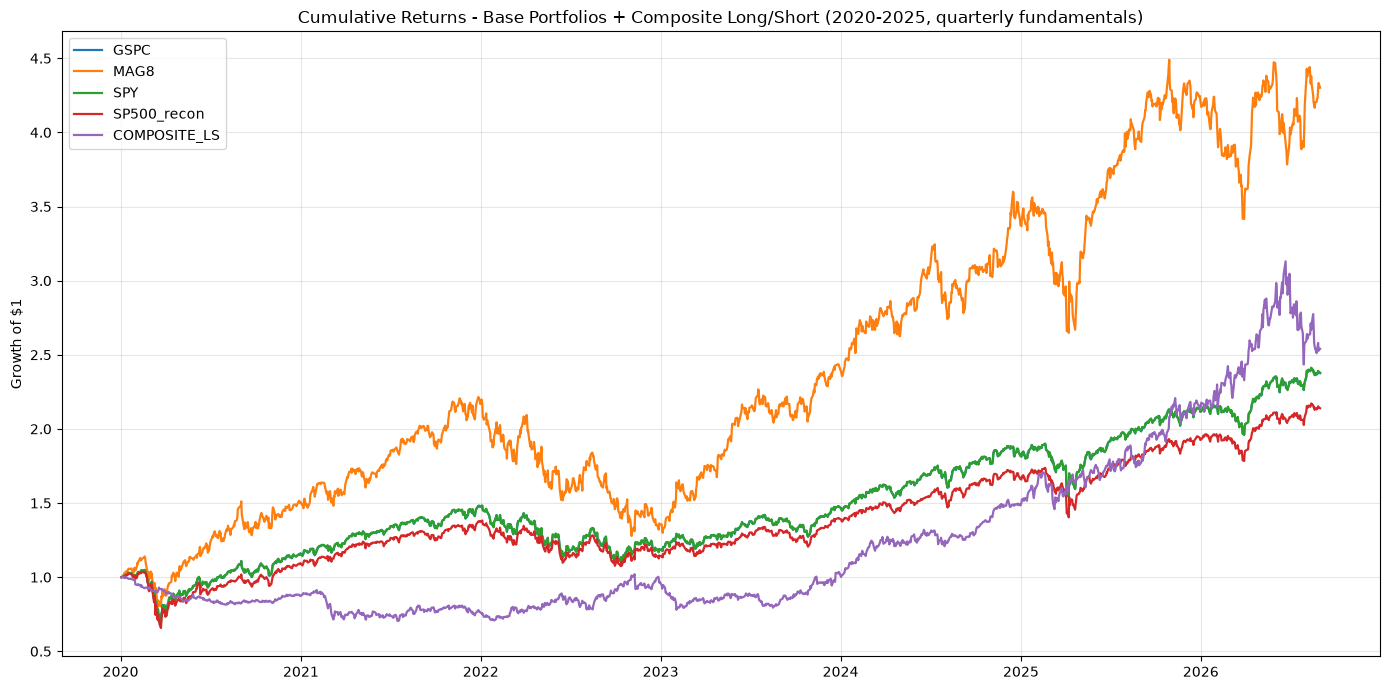

Plot saved: composite_longshort_2025.png

Full-period total returns:
portfolio_short_name
GSPC             137.6%
MAG8            330.14%
SPY             137.91%
SP500_recon     113.95%
COMPOSITE_LS    154.07%


In [14]:
# ===== Look-ahead (forward-bias) assertion =====
# Point-in-time guarantee: the dynamic scorer must NEVER use a fundamental dated
# after the rebalance quarter it is scoring. We preload every refinitiv RATIO row
# for the universe once, then for each quarter re-derive what get_panel *would*
# return (max effective_date <= quarter_end per security/metric) and confirm that
# every non-null value in the live get_panel call is sourced from on/before that
# quarter. NOTE: we restrict to RATIO_COLUMNS (the 18 ratios the factor scores) --
# shares_outstanding and other daily history are intentionally ignored by get_panel.
RATIO_SET = set(RATIO_COLUMNS)
_allf = database.read_security_fundamentals(session, engine, metric_type=None)
_allf = _allf[_allf['source_vendor'] == 'refinitiv']
_allf = _allf[_allf['security_id'].isin(uni_ids)]
_allf = _allf[_allf['metric_type'].isin(RATIO_SET)].copy()
_allf['ed'] = pd.to_datetime(_allf['effective_date'])

worst = 0
for qdt in pd.date_range(start_date, end_date, freq='QE'):
    _sd = pd.Timestamp(qdt)
    p = StaticFundamentalsProvider(session, engine, source_vendor='refinitiv').get_panel(
        sec_sym, qdt.strftime('%Y-%m-%d'))
    nn = [(s, m) for s in p.index for m in RATIO_COLUMNS if pd.notna(p.loc[s, m])]
    if not nn:
        continue
    sub = _allf[_allf['ed'] <= _sd]
    mx = sub.groupby(['security_id', 'metric_type'])['ed'].max()
    bad = [(s, m) for (s, m) in nn if (s, m) not in mx.index or mx.loc[(s, m)] > _sd]
    worst = max(worst, len(bad))
    assert not bad, f'FORWARD BIAS at {qdt.date()}: {bad[:3]}'
print('Max future-leaking fundamentals visible to scorer across all quarters (MUST be 0):', worst)
print('No-forward-bias check passed: dynamic scoring uses only point-in-time fundamentals.')

all_cum = cum_base.copy()

all_cum['COMPOSITE_LS'] = ls_cum
all_cum = all_cum.dropna(how='any')

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
for col in all_cum.columns:
    plt.plot(all_cum.index, all_cum[col], label=col, lw=1.6)
plt.title('Cumulative Returns - Base Portfolios + Composite Long/Short (2020-2025, quarterly fundamentals)')
plt.ylabel('Growth of $1')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('composite_longshort_2025.png', dpi=120)
plt.close('all')
print('Plot saved: composite_longshort_2025.png')

print('\nFull-period total returns:')
print(((all_cum.iloc[-1] / all_cum.iloc[0] - 1) * 100).round(2).astype(str).add('%').to_string())

## 7. Summary
* The four base portfolios replicate the SP500/market/benchmark structure from the demo notebook.
* The fifth portfolio (`COMPOSITE_LS`) is a momentum + ML-value long/short book.
* The composite universe is the full S&P 500 (`COMPOSITE_UNIVERSE = 'SP500'`), with Refinitiv fundamentals loaded via `toolkit/scripts/load_refinitiv_fundamentals.py --universe SP500`. MAG8 remains one of the comparison base portfolios.
